# Official V1-V6 Pipeline -- Set D (Five-Model Baseline: DT, RF, SVM, KNN, NB)

**Purpose:** This is the originally approved thesis methodology implementation. It
benchmarks the five originally approved classifiers (Decision Tree, Random Forest, SVM,
KNN, Naive Bayes) across six progressively refined pipeline versions on Set D. This is
the **primary reference result** for the thesis -- the CatBoost supplementary
experiment is a separate, later investigation and does not replace this notebook.

**Dataset:** `prepared_hsls_setD_4Y.csv` -- 12,829 records, 377 Set D predictors +
`program_stream` target.

**Target:** `program_stream` (`X4ENTRYMAJ4Y`).

**Predictors:** 377 Set D predictors.

**Experimental role:** Primary methodological benchmark. One config block
(`DATA_PATH`/`TARGET_COL`/`COLS_TO_REMOVE`/`RANDOM_STATE`) is the only thing that
should change between datasets/experiments -- this same file was used, unmodified
apart from that block, on the Alsayed 2021 benchmark validation dataset and on Set D.

**Primary metric:** Macro-F1 (test set). Chosen over accuracy because `program_stream`
is severely imbalanced across its 11 categories (695-2,266 records per class) and
Macro-F1 weights every class equally regardless of size, so the metric cannot be
inflated by performing well only on the largest classes.

**Random state:** 42.

**Preprocessing:** fitted on training folds only. `prepare_v2_style()` splits the data
into train/test *before* any imputation, encoding, or scaling; every V2-V6 pipeline
embeds a freshly-constructed, unfitted preprocessor as its own first step, so
imputation/encoding/scaling statistics are refit on only the training portion of each
individual cross-validation fold -- never on the full training split before
`cross_val_score`/`GridSearchCV` sees it, and never on the held-out test set.

**Output files produced:**
- `all_versions_summary.csv` -- best model per version
- `v1_v2_v3_per_model_results.csv` -- every model's metrics for V1-V3, saved immediately after V3 (before the slower V4-V6 stages run)
- `v4_all_feature_configs_results.csv`
- `fig_target_distribution.png`, `fig_v1_v6_macro_f1.png`
- `fig_confusion_matrix_final.png`, `final_model_classification_report.csv` (for the single best configuration found across all completed versions)

**Note on V6's base-learner hyperparameters:** the base learners inside V6's stacking
ensemble are cloned from **this run's own V5 tuned models** (`clone()` of the fitted
pipeline's model step), not hardcoded from a different dataset/run -- this makes the
same file correct across datasets with no code edit. (An earlier version of this
notebook's design summary incorrectly described this as using fixed, hardcoded
hyperparameters; that was a stale comment, not the actual behaviour, and has been
corrected here.)


## V1-V6 progression at a glance

| Version | What changes | Notes |
|---|---|---|
| V1 | Complete-case baseline | `dropna()`, label-encode, no scaling, no SMOTE. Split happens *after* dropping incomplete rows. |
| V2 | Imputation + scaling | Split *before* preprocessing; mean/median impute, ordinal-encode, MinMaxScaler -- all fit on the training fold only. |
| V3 | V2 + SMOTE | SMOTE nested inside the pipeline, refit per fold (training-fold-only oversampling). |
| V4 | V2 + feature selection | Chi-square / RFE / RF-importance compared across up to 8 feature configurations, each run through SMOTE. |
| V5 | Tuning | RFE-Top-20 (this dataset's actual `K20`) + SMOTE + `GridSearchCV` hyperparameter tuning, one grid per model. |
| V6 | Stacking ensemble | RFE-Top-20 + SMOTE + `Stacking(RF + SVM + NB -> LogisticRegression)`, base learners cloned from this run's own V5 tuned models. |


## (Optional) Mount Google Drive
Run this if `DATA_PATH` below points to a file in Google Drive.

In [1]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print("Not running in Colab -- skipping Drive mount (expected for local VS Code runs).")


Not running in Colab -- skipping Drive mount (expected for local VS Code runs).


## Install / Import

In [2]:
!pip install imbalanced-learn --quiet

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, MinMaxScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.base import clone, BaseEstimator, TransformerMixin
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, chi2, RFE
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


### CONFIG -- the only section that changes per dataset/experiment

In [3]:
DATA_PATH      = "/Users/narjishubail/Downloads/new/prepared_hsls_setD_4Y.csv"   # output of prepare_dataset_for_pipeline (CONFIG_SET_D_4Y)
TARGET_COL     = "program_stream"
COLS_TO_REMOVE = []
RANDOM_STATE   = 42

EXPERIMENT_TAG = "official_v1_v6_setD"   # all outputs from THIS file are prefixed with this

# All CSVs and figures this notebook saves are written under OUTPUT_DIR, not the
# notebook's default working directory -- so results land in the same Drive folder as
# the input files above instead of Colab's ephemeral /content/.
OUTPUT_DIR = "/Users/narjishubail/Downloads/new/output"

def out_path(filename: str) -> str:
    """Join a bare output filename onto OUTPUT_DIR."""
    return f"{OUTPUT_DIR.rstrip('/')}/{filename}"

# V4/V5/V6's "Top 15"/"Top 20" feature-selection targets are computed dynamically per
# dataset inside prepare_v2_style() as K15=min(15, n_features), K20=min(20, n_features) --
# this is what lets one file work across datasets with very different predictor counts
# without editing code. RFE_STEP=1 matches the individual V1-V6 notebooks exactly
# (remove one feature per elimination round); this is slow once feature counts get
# large (e.g. Set D's 377 candidates) but is what the individual notebooks actually
# used, so it stays the default here for benchmark parity.
RFE_STEP = 1

# V5 tuning uses GridSearchCV (exhaustive grid search) to match the individual V1-V6
# notebooks, not RandomizedSearchCV.


### SHARED: load data, evaluation helpers, preprocessing

Kept byte-for-byte identical to the original file's logic -- only debug clutter and
stale comments were removed.

In [4]:
def load_data(path: str, target_col: str, cols_to_remove: list) -> pd.DataFrame:
    df = pd.read_csv(path)
    present = [c for c in cols_to_remove if c in df.columns]
    if present:
        df = df.drop(columns=present)
    if df[target_col].isnull().sum() > 0:
        before = len(df)
        df = df.dropna(subset=[target_col]).reset_index(drop=True)
        print(f"Dropped {before - len(df)} rows with missing target.")
    print(f"Loaded: {df.shape[0]} rows x {df.shape[1]} columns")
    return df


def diagnose(f1_train, f1_test):
    gap = f1_train - f1_test
    if gap > 0.15:
        return gap, "OVERFIT"
    elif f1_test < 0.50 and f1_train < 0.50:
        return gap, "UNDERFIT"
    return gap, "GOOD FIT"


def evaluate(model, X_train, y_train, X_test, y_test, cv, name, extra=None):
    y_pred = model.predict(X_test)
    y_train_pred = model.predict(X_train)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_test, y_pred, average="macro", zero_division=0)
    f1_test = f1_score(y_test, y_pred, average="macro", zero_division=0)
    f1_train = f1_score(y_train, y_train_pred, average="macro", zero_division=0)
    gap, diag = diagnose(f1_train, f1_test)

    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1_macro", n_jobs=-1)

    row = {
        "Model": name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1 Test": round(f1_test, 4),
        "F1 Train": round(f1_train, 4),
        "Train-Test Gap": round(gap, 4),
        "CV Mean": round(cv_scores.mean(), 4),
        "CV Std": round(cv_scores.std(), 4),
        "Diagnosis": diag,
    }
    if extra:
        row.update(extra)
    return row


BASE_MODEL_DEFS = lambda: {
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    "SVM": SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
}


def smote_k_for(y_train):
    min_class_count = pd.Series(y_train).value_counts().min()
    return max(1, min(5, min_class_count - 1))


def make_cv(y):
    """StratifiedKFold with n_splits capped by the smallest class's size, not
    hardcoded to 5 -- a class with only 2-3 members can't support 5-fold CV."""
    min_class_count = pd.Series(y).value_counts().min()
    n_splits = min(5, int(min_class_count))
    if n_splits < 2:
        raise ValueError(
            f"Cross-validation impossible: smallest class has only "
            f"{min_class_count} sample(s), need at least 2 for any CV split."
        )
    if n_splits < 5:
        print(f"  NOTE: smallest class has {min_class_count} samples -- "
              f"using {n_splits}-fold CV instead of the default 5-fold.")
    return StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)


class ColumnIndexSelector(BaseEstimator, TransformerMixin):
    """Selects fixed column positions from an already-preprocessed array. Used by V4
    to apply its one-time feature ranking (chi2/RFE/RF-importance, computed once --
    exploratory, matches the original V4 design) inside a pipeline whose
    IMPUTATION/ENCODING/SCALING still gets refit fresh per CV fold."""
    def __init__(self, indices):
        self.indices = indices
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return X[:, self.indices]


def determine_column_types(df_train_raw: pd.DataFrame, target_col: str):
    """Classifies each predictor as continuous/discrete/categorical from the training
    schema -- a one-time structural decision, not a fold-sensitive statistic."""
    numeric_cols = df_train_raw.select_dtypes(include="number").columns.tolist()
    categorical_cols = [c for c in df_train_raw.select_dtypes(include="object").columns if c != target_col]
    continuous_cols, discrete_cols = [], []
    for col in numeric_cols:
        if col == target_col:
            continue
        non_null = df_train_raw[col].dropna()
        is_integer = non_null.apply(lambda x: x == int(x)).all() if len(non_null) else True
        n_unique = df_train_raw[col].nunique()
        if is_integer and n_unique <= 20:
            discrete_cols.append(col)
        else:
            continuous_cols.append(col)
    return continuous_cols, discrete_cols, categorical_cols


def build_preprocessor(continuous_cols, discrete_cols, categorical_cols):
    """Unfitted ColumnTransformer: mean-impute continuous, median-impute discrete,
    mode-impute + ordinal-encode categorical (unseen categories map to -1). Nothing is
    fit here -- fitting happens fresh each time this is cloned into a Pipeline and
    that Pipeline is fit, which is what keeps this fold-safe."""
    continuous_pipe = SkPipeline([("impute", SimpleImputer(strategy="mean"))])
    discrete_pipe = SkPipeline([("impute", SimpleImputer(strategy="median"))])
    categorical_pipe = SkPipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("encode", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
    ])
    return ColumnTransformer(transformers=[
        ("cont", continuous_pipe, continuous_cols),
        ("disc", discrete_pipe, discrete_cols),
        ("cat", categorical_pipe, categorical_cols),
    ])


### V1 -- Raw baseline: dropna, label-encode, no scaling, no SMOTE

Also returns a `candidates` list (fitted model + the exact test data it was scored on,
per row) alongside the results DataFrame -- purely additive, so the notebook can later
produce a confusion matrix/classification report for whichever single model turns out
to be the overall best across all completed versions, without changing any number
already being reported.

In [5]:
def run_v1(df: pd.DataFrame):
    print("\n" + "=" * 70)
    print("V1 -- Raw baseline (dropna, label-encode, no scaling, no SMOTE)")
    print("=" * 70)

    df_v1 = df.dropna().copy()
    print(f"Records after dropna: {len(df_v1)} (from {len(df)})")

    X_raw = df_v1.drop(columns=[TARGET_COL])
    y_raw = df_v1[TARGET_COL]

    X_train_raw, X_test_raw, y_train_labels, y_test_labels = train_test_split(
        X_raw, y_raw, test_size=0.2, random_state=RANDOM_STATE, stratify=y_raw
    )

    label_encoders = {}
    X_train = X_train_raw.copy()
    X_test = X_test_raw.copy()
    cat_cols = X_train_raw.select_dtypes(include="object").columns.tolist()

    for col in cat_cols:
        le = LabelEncoder()
        X_train[col] = le.fit_transform(X_train_raw[col].astype(str))
        known = set(le.classes_)
        test_vals = X_test_raw[col].astype(str)
        unseen = ~test_vals.isin(known)
        encoded_test = np.full(len(test_vals), -1, dtype=int)
        encoded_test[~unseen] = le.transform(test_vals[~unseen])
        X_test[col] = encoded_test
        label_encoders[col] = le

    le_target = LabelEncoder()
    le_target.fit(y_train_labels)
    y_train = le_target.transform(y_train_labels)
    y_test = le_target.transform(y_test_labels)

    cv = make_cv(y_train)
    results = []
    candidates = []
    for name, model in BASE_MODEL_DEFS().items():
        model.fit(X_train, y_train)
        row = evaluate(model, X_train, y_train, X_test, y_test, cv, name)
        results.append(row)
        candidates.append({"row": row, "model": model, "X_test": X_test, "y_test": y_test})
        print(f"  {name:<15} F1 Test: {row['F1 Test']:.4f}  ({row['Diagnosis']})")

    return pd.DataFrame(results), candidates


### SHARED: V2-V6 preprocessing (split before impute, then scale)

In [6]:
def prepare_v2_style(df: pd.DataFrame):
    """Split BEFORE any preprocessing (key structural fix vs V1). Only column TYPES
    (continuous/discrete/categorical) are determined here -- a structural decision, not
    a fold-sensitive statistic. Returns the raw train/test feature frames plus a
    make_preprocessor() factory that builds a fresh, unfitted ColumnTransformer, so
    imputation/encoding/scaling statistics get refit on only the training portion of
    each CV fold -- not on the full training split before CV/GridSearchCV ever sees
    it, and not on the test set."""
    target_missing = df[TARGET_COL].isnull().sum()
    if target_missing > 0:
        df = df.dropna(subset=[TARGET_COL]).reset_index(drop=True)

    train_idx, test_idx = train_test_split(
        df.index, test_size=0.2, random_state=RANDOM_STATE, stratify=df[TARGET_COL]
    )
    df_train_raw = df.loc[train_idx].copy()
    df_test_raw = df.loc[test_idx].copy()

    continuous_cols, discrete_cols, categorical_cols = determine_column_types(df_train_raw, TARGET_COL)
    feature_names = continuous_cols + discrete_cols + categorical_cols

    X_train_raw = df_train_raw[feature_names]
    X_test_raw = df_test_raw[feature_names]

    le_target = LabelEncoder()
    le_target.fit(df_train_raw[TARGET_COL])
    y_train = le_target.transform(df_train_raw[TARGET_COL])
    y_test = le_target.transform(df_test_raw[TARGET_COL])

    n_features = len(feature_names)
    K15 = min(15, n_features)
    K20 = min(20, n_features)
    print(f"Available predictors: {n_features} (continuous={len(continuous_cols)}, "
          f"discrete={len(discrete_cols)}, categorical={len(categorical_cols)})")
    print(f"V4 small feature set (K15): {K15}")
    print(f"V4/V5/V6 feature set (K20): {K20}")
    if K15 == n_features:
        print(f"  NOTE: K15 == all available predictors -- feature-selection "
              f"reduction is not applicable at the 15-feature threshold for this dataset.")
    if K20 == n_features and K20 != K15:
        print(f"  NOTE: K20 == all available predictors -- feature-selection "
              f"reduction is not applicable at the 20-feature threshold for this dataset.")

    def make_preprocessor():
        return build_preprocessor(continuous_cols, discrete_cols, categorical_cols)

    return {
        "X_train_raw": X_train_raw,
        "X_test_raw": X_test_raw,
        "y_train": y_train,
        "y_test": y_test,
        "feature_names": feature_names,
        "continuous_cols": continuous_cols,
        "discrete_cols": discrete_cols,
        "categorical_cols": categorical_cols,
        "make_preprocessor": make_preprocessor,
        "le_target": le_target,
        "n_features": n_features,
        "K15": K15, "K20": K20,
    }


### V2 -- Imputed + scaled, no SMOTE

In [7]:
def run_v2(prep: dict):
    print("\n" + "=" * 70)
    print("V2 -- Imputed + scaled (fold-safe), no SMOTE")
    print("=" * 70)

    X_train, X_test = prep["X_train_raw"], prep["X_test_raw"]
    y_train, y_test = prep["y_train"], prep["y_test"]
    cv = make_cv(y_train)

    results = []
    candidates = []
    for name, model in BASE_MODEL_DEFS().items():
        pipe = SkPipeline([
            ("preprocess", prep["make_preprocessor"]()),
            ("scale", MinMaxScaler()),
            ("model", model),
        ])
        pipe.fit(X_train, y_train)
        row = evaluate(pipe, X_train, y_train, X_test, y_test, cv, name)
        results.append(row)
        candidates.append({"row": row, "model": pipe, "X_test": X_test, "y_test": y_test})
        print(f"  {name:<15} F1 Test: {row['F1 Test']:.4f}  ({row['Diagnosis']})")

    return pd.DataFrame(results), candidates


### V3 -- V2 + SMOTE (nested inside the pipeline, refit per fold)

In [8]:
def run_v3(prep: dict):
    print("\n" + "=" * 70)
    print("V3 -- Imputed + scaled (fold-safe) + SMOTE")
    print("=" * 70)

    X_train, X_test = prep["X_train_raw"], prep["X_test_raw"]
    y_train, y_test = prep["y_train"], prep["y_test"]
    cv = make_cv(y_train)
    smote_k = smote_k_for(y_train)
    print(f"SMOTE k_neighbors={smote_k}")

    results = []
    candidates = []
    for name, model in BASE_MODEL_DEFS().items():
        pipe = ImbPipeline([
            ("preprocess", prep["make_preprocessor"]()),
            ("scale", MinMaxScaler()),
            ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=smote_k)),
            ("model", model),
        ])
        pipe.fit(X_train, y_train)
        row = evaluate(pipe, X_train, y_train, X_test, y_test, cv, name)
        results.append(row)
        candidates.append({"row": row, "model": pipe, "X_test": X_test, "y_test": y_test})
        print(f"  {name:<15} F1 Test: {row['F1 Test']:.4f}  ({row['Diagnosis']})")

    return pd.DataFrame(results), candidates


### V4 -- V2 + feature selection (Chi2 / RFE / RF-importance), up to 8 configs

In [9]:
def run_v4(prep: dict):
    print("\n" + "=" * 70)
    print("V4 -- Feature selection (Chi2 / RFE / RF importance)")
    print("=" * 70)

    X_train_raw, X_test_raw = prep["X_train_raw"], prep["X_test_raw"]
    y_train, y_test = prep["y_train"], prep["y_test"]
    feature_names = prep["feature_names"]
    K15, K20 = prep["K15"], prep["K20"]
    cv = make_cv(y_train)
    smote_k = smote_k_for(y_train)

    if K15 == K20:
        # K15 == min(15, n) and K20 == min(20, n) can only be equal when n <= 15 --
        # this dataset has too few predictors for the 15-vs-20 comparison to mean
        # anything. Report this honestly as one config instead of manufacturing a
        # false comparison.
        print(f"NOTE: K15 == K20 == {K15} (all available predictors) -- "
              f"feature-selection reduction is not applicable for this dataset. "
              f"Reporting a single 'all features' configuration instead of 8 "
              f"reordered copies of the same feature set.")
        feature_configs = {"All features (selection not applicable)": feature_names}
        v4_feature_sets = {"selection_not_applicable": True, "all_features": feature_names}
    else:
        # One-time preprocessing fit on the full training split, used ONLY to RANK
        # features for choosing which columns go into each config below -- a one-time
        # exploratory step, not something refit per fold. What DOES get refit per
        # fold is the actual model scoring further down.
        exploratory_pre = SkPipeline([
            ("preprocess", prep["make_preprocessor"]()),
            ("scale", MinMaxScaler()),
        ])
        X_train_for_ranking = exploratory_pre.fit_transform(X_train_raw)

        chi2_selector = SelectKBest(score_func=chi2, k="all")
        chi2_selector.fit(X_train_for_ranking, y_train)
        chi2_ranked = pd.Series(chi2_selector.scores_, index=feature_names).sort_values(ascending=False)
        chi2_top15 = list(chi2_ranked.head(K15).index)
        chi2_top20 = list(chi2_ranked.head(K20).index)

        rf_for_rfe = RandomForestClassifier(n_estimators=50, random_state=RANDOM_STATE, n_jobs=-1)
        rfe15 = RFE(estimator=rf_for_rfe, n_features_to_select=K15, step=RFE_STEP).fit(X_train_for_ranking, y_train)
        rfe_top15 = list(pd.Series(rfe15.ranking_, index=feature_names).pipe(lambda s: s[s == 1].index))
        rfe20 = RFE(estimator=rf_for_rfe, n_features_to_select=K20, step=RFE_STEP).fit(X_train_for_ranking, y_train)
        rfe_top20 = list(pd.Series(rfe20.ranking_, index=feature_names).pipe(lambda s: s[s == 1].index))

        rf_importance = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
        rf_importance.fit(X_train_for_ranking, y_train)
        importances_ranked = pd.Series(rf_importance.feature_importances_, index=feature_names).sort_values(ascending=False)
        rf_top15 = list(importances_ranked.head(K15).index)
        rf_top20 = list(importances_ranked.head(K20).index)

        in_all_three = set(chi2_top15) & set(rfe_top15) & set(rf_top15)

        feature_configs = {
            "All features (V3 baseline)": feature_names,
            f"Chi-Square Top {K15}": chi2_top15,
            f"Chi-Square Top {K20}": chi2_top20,
            f"RFE Top {K15}": rfe_top15,
            f"RFE Top {K20}": rfe_top20,
            f"RF Importance Top {K15}": rf_top15,
            f"RF Importance Top {K20}": rf_top20,
            "Consensus (all 3 methods)": sorted(list(in_all_three)),
        }
        v4_feature_sets = {
            "chi2_top20": chi2_top20, "rfe_top20": rfe_top20, "rf_top20": rf_top20,
            "consensus": sorted(list(in_all_three)),
        }

    print(f"Feature configurations to test ({len(feature_configs)}):")
    for name, feats in feature_configs.items():
        print(f"  {name:<30} {len(feats)} features")

    results = []
    candidates = []
    for config_name, selected_features in feature_configs.items():
        if len(selected_features) == 0:
            continue
        idx = [feature_names.index(f) for f in selected_features if f in feature_names]

        for model_name, base_model in BASE_MODEL_DEFS().items():
            pipe = ImbPipeline([
                ("preprocess", prep["make_preprocessor"]()),
                ("scale", MinMaxScaler()),
                ("select", ColumnIndexSelector(idx)),
                ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=smote_k)),
                ("clf", base_model),
            ])
            pipe.fit(X_train_raw, y_train)
            row = evaluate(pipe, X_train_raw, y_train, X_test_raw, y_test, cv, model_name,
                            extra={"Feature Config": config_name, "N Features": len(idx)})
            results.append(row)
            candidates.append({"row": row, "model": pipe, "X_test": X_test_raw, "y_test": y_test})

        best_this_config = max(
            (r for r in results if r["Feature Config"] == config_name),
            key=lambda r: r["F1 Test"],
        )
        print(f"  Best in '{config_name}': {best_this_config['Model']} "
              f"(F1 Test={best_this_config['F1 Test']:.4f})")

    results_df = pd.DataFrame(results)
    return results_df, v4_feature_sets, candidates


### V5 -- RFE-Top-20 (V4's winning feature-count threshold) + SMOTE + GridSearchCV tuning

In [10]:
def run_v5(prep: dict):
    print("\n" + "=" * 70)
    print(f"V5 -- RFE Top {prep['K20']} + SMOTE + GridSearchCV tuning")
    print("=" * 70)

    X_train, X_test = prep["X_train_raw"], prep["X_test_raw"]
    y_train, y_test = prep["y_train"], prep["y_test"]
    cv = make_cv(y_train)
    smote_k = smote_k_for(y_train)

    def make_selector():
        return RFE(
            estimator=RandomForestClassifier(n_estimators=50, random_state=RANDOM_STATE, n_jobs=-1),
            n_features_to_select=prep["K20"], step=RFE_STEP,
        )

    base_models = BASE_MODEL_DEFS()
    pipelines = {
        name: ImbPipeline([
            ("preprocess", prep["make_preprocessor"]()),
            ("scale", MinMaxScaler()),
            ("select", make_selector()),
            ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=smote_k)),
            ("model", model),
        ])
        for name, model in base_models.items()
    }

    param_grids = {
        "Decision Tree": {
            "model__max_depth": [3, 5, 7, 10, None],
            "model__min_samples_leaf": [1, 2, 5, 10],
            "model__criterion": ["gini", "entropy"],
        },
        "Random Forest": {
            "model__n_estimators": [100, 200, 300],
            "model__max_depth": [5, 10, 20, None],
            "model__min_samples_leaf": [1, 2, 5],
        },
        "SVM": {
            "model__C": [0.1, 1, 10, 100],
            "model__gamma": ["scale", "auto", 0.01, 0.1],
        },
        "KNN": {
            "model__n_neighbors": [3, 5, 7, 9, 11, 15],
            "model__weights": ["uniform", "distance"],
        },
        "Naive Bayes": {
            "model__var_smoothing": np.logspace(0, -9, 10),
        },
    }

    results = []
    tuned_models = {}
    candidates = []
    for model_name, pipeline in pipelines.items():
        print(f"\nTuning: {model_name}")
        # GridSearchCV -- exhaustive search over every combination in
        # param_grids[model_name], matching the individual V5 notebook.
        grid = GridSearchCV(
            estimator=pipeline, param_grid=param_grids[model_name],
            cv=cv, scoring="f1_macro", n_jobs=-1, refit=True,
        )
        grid.fit(X_train, y_train)
        best = grid.best_estimator_
        tuned_models[model_name] = best
        print(f"  Best params: {grid.best_params_}")

        row = evaluate(best, X_train, y_train, X_test, y_test, cv, model_name,
                        extra={"Best Params": str(grid.best_params_)})
        results.append(row)
        candidates.append({"row": row, "model": best, "X_test": X_test, "y_test": y_test})
        print(f"  F1 Test: {row['F1 Test']:.4f}  ({row['Diagnosis']})")

    return pd.DataFrame(results), tuned_models, candidates


### V6 -- Stacking ensemble: RFE-Top-20 + SMOTE + Stacking(RF+SVM+NB -> LogReg)

In [11]:
def run_v6(prep: dict, v5_tuned_models: dict = None):
    print("\n" + "=" * 70)
    print("V6 -- Stacking ensemble (RF + SVM + NB -> Logistic Regression)")
    print("=" * 70)

    X_train, X_test = prep["X_train_raw"], prep["X_test_raw"]
    y_train, y_test = prep["y_train"], prep["y_test"]
    cv = make_cv(y_train)
    smote_k = smote_k_for(y_train)

    def make_selector():
        return RFE(
            estimator=RandomForestClassifier(n_estimators=50, random_state=RANDOM_STATE, n_jobs=-1),
            n_features_to_select=prep["K20"], step=RFE_STEP,
        )

    # DYNAMIC handoff: base learners use THIS dataset's V5 tuned hyperparameters, via
    # clone() of the fitted pipeline's model step -- not hardcoded constants from a
    # different dataset/run. This is what makes V6 correct across datasets.
    def get_tuned(name, fallback):
        if v5_tuned_models and name in v5_tuned_models:
            try:
                return clone(v5_tuned_models[name].named_steps["model"])
            except Exception as e:
                print(f"  WARNING: could not clone tuned {name} ({e}), using fallback default.")
        else:
            print(f"  NOTE: no V5 tuned model found for {name} -- using fallback default "
                  f"(V5 may have failed, or wasn't run first).")
        return fallback

    rf = get_tuned("Random Forest", RandomForestClassifier(
        n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1))
    svm = get_tuned("SVM", SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE))
    nb = get_tuned("Naive Bayes", GaussianNB())

    base_estimators = [("rf", rf), ("svm", svm), ("nb", nb)]
    print("Base learners (tuned params from this dataset's V5, where available):")
    for name, est in base_estimators:
        print(f"  {name}: {est}")

    stacking_model = StackingClassifier(
        estimators=base_estimators,
        final_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        cv=cv, n_jobs=-1,
    )

    pipeline_v6 = ImbPipeline([
        ("preprocess", prep["make_preprocessor"]()),
        ("scale", MinMaxScaler()),
        ("select", make_selector()),
        ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=smote_k)),
        ("model", stacking_model),
    ])

    pipeline_v6.fit(X_train, y_train)
    row = evaluate(pipeline_v6, X_train, y_train, X_test, y_test, cv,
                    "Stacking (RF+SVM+NB -> LogReg)")
    print(f"  F1 Test: {row['F1 Test']:.4f}  ({row['Diagnosis']})")

    candidates = [{"row": row, "model": pipeline_v6, "X_test": X_test, "y_test": y_test}]
    return pd.DataFrame([row]), candidates


### MAIN -- run all six versions, save incrementally, and identify the overall best configuration

V1-V3 per-model results are saved to CSV **immediately after V3 completes**, before the
slower V4-V6 stages run -- so an interruption during V5 (the most expensive, most
interruption-prone stage) does not lose V1-V3. All fitted candidates across every
completed version are tracked so a final confusion matrix / classification report can
be produced for whichever single configuration turns out to be the overall best,
without re-fitting anything or changing any reported number.

In [12]:
def main():
    df = load_data(DATA_PATH, TARGET_COL, COLS_TO_REMOVE)

    results = {}
    all_candidates = []

    def safe_run(label, fn, *args):
        try:
            out = fn(*args)
            return out, None
        except Exception as e:
            print(f"\n*** {label} FAILED: {e} ***")
            print(f"*** This is reported, not hidden -- see summary at the end. ***")
            return None, str(e)

    v1_out, v1_err = safe_run("V1", run_v1, df)
    if v1_out is not None:
        v1_df, v1_candidates = v1_out
        results["v1"] = v1_df
        all_candidates.extend([{"Version": "V1", **c} for c in v1_candidates])
    else:
        v1_df = None

    prep = prepare_v2_style(df)  # V2-V6 share this; let it raise loudly if it fails

    v2_out, v2_err = safe_run("V2", run_v2, prep)
    if v2_out is not None:
        v2_df, v2_candidates = v2_out
        results["v2"] = v2_df
        all_candidates.extend([{"Version": "V2", **c} for c in v2_candidates])
    else:
        v2_df = None

    v3_out, v3_err = safe_run("V3", run_v3, prep)
    if v3_out is not None:
        v3_df, v3_candidates = v3_out
        results["v3"] = v3_df
        all_candidates.extend([{"Version": "V3", **c} for c in v3_candidates])
    else:
        v3_df = None

    # --- Save V1-V3 per-model results NOW, before V4-V6 run ---
    per_model_frames = []
    for version_label, df_results in [("V1", v1_df), ("V2", v2_df), ("V3", v3_df)]:
        if df_results is None:
            continue
        tagged = df_results.copy()
        tagged.insert(0, "Version", version_label)
        per_model_frames.append(tagged)
    if per_model_frames:
        per_model_results = pd.concat(per_model_frames, ignore_index=True)
        per_model_path = out_path(f"{EXPERIMENT_TAG}_v1_v2_v3_per_model_results.csv")
        per_model_results.to_csv(per_model_path, index=False)
        print(f"\nSaved (early, before V4-V6): {per_model_path}")
        results["per_model_results"] = per_model_results

    v4_out, v4_err = safe_run("V4", run_v4, prep)
    if v4_out is not None:
        v4_df, v4_feature_sets, v4_candidates = v4_out
        results["v4"] = v4_df
        all_candidates.extend([{"Version": "V4", **c} for c in v4_candidates])
    else:
        v4_df = None

    v5_out, v5_err = safe_run("V5", run_v5, prep)
    if v5_out is not None:
        v5_df, v5_tuned_models, v5_candidates = v5_out
        results["v5"] = v5_df
        all_candidates.extend([{"Version": "V5", **c} for c in v5_candidates])
    else:
        v5_df, v5_tuned_models = None, None

    v6_out, v6_err = safe_run("V6", run_v6, prep, v5_tuned_models)
    if v6_out is not None:
        v6_df, v6_candidates = v6_out
        results["v6"] = v6_df
        all_candidates.extend([{"Version": "V6", **c} for c in v6_candidates])
    else:
        v6_df = None

    def best_row(df_results, version_label, err):
        if df_results is None:
            return {"Version": version_label, "Best Model": "FAILED", "F1 Test": None, "Note": err}
        best = df_results.loc[df_results["F1 Test"].idxmax()]
        return {"Version": version_label, "Best Model": best["Model"], "F1 Test": best["F1 Test"], "Note": ""}

    summary = pd.DataFrame([
        best_row(v1_df, "V1 (raw baseline)", v1_err),
        best_row(v2_df, "V2 (imputed + scaled)", v2_err),
        best_row(v3_df, "V3 (+ SMOTE)", v3_err),
        best_row(v4_df, "V4 (+ feature selection)", v4_err),
        best_row(v5_df, "V5 (+ hyperparameter tuning)", v5_err),
        best_row(v6_df, "V6 (stacking ensemble)", v6_err),
    ])

    print("\n" + "=" * 70)
    print("FINAL V1 -> V6 COMPARISON (best model per version, by F1 Test)")
    print("=" * 70)
    print(summary.to_string(index=False))

    summary_path = out_path(f"{EXPERIMENT_TAG}_all_versions_summary.csv")
    summary.to_csv(summary_path, index=False)
    saved = [summary_path]
    if v4_df is not None:
        v4_path = out_path(f"{EXPERIMENT_TAG}_v4_all_feature_configs_results.csv")
        v4_df.to_csv(v4_path, index=False)
        saved.append(v4_path)
    print(f"\nSaved: {', '.join(saved)}")

    results["summary"] = summary
    results["all_candidates"] = all_candidates
    return results


## Class distribution

Plotted before running any version, from the full loaded dataset -- shows the severe
imbalance across `program_stream`'s 11 categories that motivates using Macro-F1 as the
primary metric.

Loaded: 12829 rows x 378 columns
program_stream
-1.0      695
 1.0      493
 2.0     1166
 3.0     1645
 4.0      270
 5.0      966
 6.0      748
 7.0     2266
 8.0     1728
 9.0      760
 10.0    2092
Name: count, dtype: int64


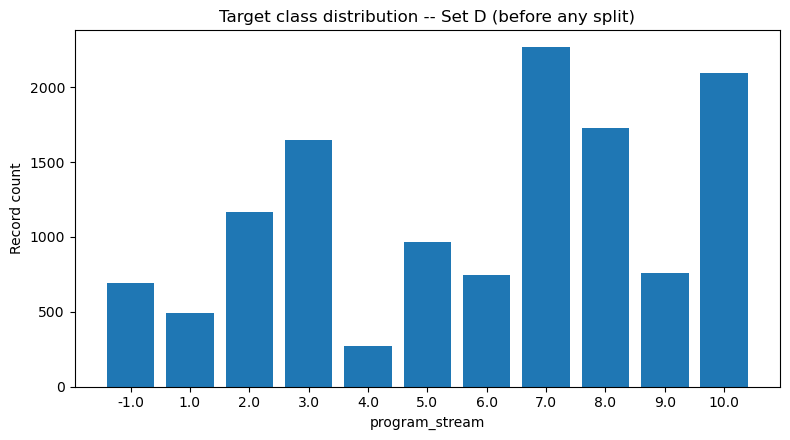

In [13]:
df_preview = load_data(DATA_PATH, TARGET_COL, COLS_TO_REMOVE)
class_counts = df_preview[TARGET_COL].value_counts().sort_index()
print(class_counts)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(class_counts.index.astype(str), class_counts.values)
ax.set_xlabel(TARGET_COL)
ax.set_ylabel("Record count")
ax.set_title("Target class distribution -- Set D (before any split)")
plt.tight_layout()
plt.savefig(out_path("fig_target_distribution.png"), dpi=200)
plt.show()


## Run all six versions

In [14]:
results = main()


Loaded: 12829 rows x 378 columns

V1 -- Raw baseline (dropna, label-encode, no scaling, no SMOTE)
Records after dropna: 662 (from 12829)
  Decision Tree   F1 Test: 0.0786  (OVERFIT)
  Random Forest   F1 Test: 0.1209  (OVERFIT)
  SVM             F1 Test: 0.0301  (UNDERFIT)
  KNN             F1 Test: 0.0925  (OVERFIT)
  Naive Bayes     F1 Test: 0.2455  (OVERFIT)
Available predictors: 377 (continuous=42, discrete=335, categorical=0)
V4 small feature set (K15): 15
V4/V5/V6 feature set (K20): 20

V2 -- Imputed + scaled (fold-safe), no SMOTE
  Decision Tree   F1 Test: 0.1454  (OVERFIT)
  Random Forest   F1 Test: 0.1588  (OVERFIT)
  SVM             F1 Test: 0.1966  (UNDERFIT)
  KNN             F1 Test: 0.1528  (OVERFIT)
  Naive Bayes     F1 Test: 0.1118  (UNDERFIT)

V3 -- Imputed + scaled (fold-safe) + SMOTE
SMOTE k_neighbors=5
  Decision Tree   F1 Test: 0.1463  (OVERFIT)
  Random Forest   F1 Test: 0.2089  (OVERFIT)


Exception ignored in: <function ResourceTracker.__del__ at 0x107621bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1058fdbc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x105bd1bc0>
Traceback (most recent call last

  SVM             F1 Test: 0.2271  (OVERFIT)
  KNN             F1 Test: 0.0960  (OVERFIT)
  Naive Bayes     F1 Test: 0.1381  (UNDERFIT)

Saved (early, before V4-V6): /Users/narjishubail/Downloads/new/output/official_v1_v6_setD_v1_v2_v3_per_model_results.csv

V4 -- Feature selection (Chi2 / RFE / RF importance)
Feature configurations to test (8):
  All features (V3 baseline)     377 features
  Chi-Square Top 15              15 features
  Chi-Square Top 20              20 features
  RFE Top 15                     15 features
  RFE Top 20                     20 features
  RF Importance Top 15           15 features
  RF Importance Top 20           20 features
  Consensus (all 3 methods)      0 features


Exception ignored in: <function ResourceTracker.__del__ at 0x10508dbc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x105031bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x10656dbc0>
Traceback (most recent call last

  Best in 'All features (V3 baseline)': SVM (F1 Test=0.2271)
  Best in 'Chi-Square Top 15': SVM (F1 Test=0.1662)
  Best in 'Chi-Square Top 20': SVM (F1 Test=0.1688)
  Best in 'RFE Top 15': Random Forest (F1 Test=0.1419)
  Best in 'RFE Top 20': SVM (F1 Test=0.1342)
  Best in 'RF Importance Top 15': SVM (F1 Test=0.1246)
  Best in 'RF Importance Top 20': Random Forest (F1 Test=0.1322)

V5 -- RFE Top 20 + SMOTE + GridSearchCV tuning

Tuning: Decision Tree
  Best params: {'model__criterion': 'gini', 'model__max_depth': 10, 'model__min_samples_leaf': 5}


...

  Best params: {'model__var_smoothing': np.float64(0.01)}


Exception ignored in: <function ResourceTracker.__del__ at 0x1048b1bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x10596dbc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x10586dbc0>
Traceback (most recent call last

  F1 Test: 0.1030  (UNDERFIT)

V6 -- Stacking ensemble (RF + SVM + NB -> Logistic Regression)
Base learners (tuned params from this dataset's V5, where available):
  rf: RandomForestClassifier(max_depth=10, n_jobs=-1, random_state=42)
  svm: SVC(C=100, gamma=0.01, probability=True, random_state=42)
  nb: GaussianNB(var_smoothing=np.float64(0.01))


Exception ignored in: <function ResourceTracker.__del__ at 0x105b6dbc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x102e7dbc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x102891bc0>
Traceback (most recent call last

  F1 Test: 0.1251  (OVERFIT)

FINAL V1 -> V6 COMPARISON (best model per version, by F1 Test)
                     Version                     Best Model  F1 Test Note
           V1 (raw baseline)                    Naive Bayes   0.2455     
       V2 (imputed + scaled)                            SVM   0.1966     
                V3 (+ SMOTE)                            SVM   0.2271     
    V4 (+ feature selection)                            SVM   0.2271     
V5 (+ hyperparameter tuning)                  Random Forest   0.1253     
      V6 (stacking ensemble) Stacking (RF+SVM+NB -> LogReg)   0.1251     

Saved: /Users/narjishubail/Downloads/new/output/official_v1_v6_setD_all_versions_summary.csv, /Users/narjishubail/Downloads/new/output/official_v1_v6_setD_v4_all_feature_configs_results.csv


## Model-comparison figure for the main versions

Built from `results["summary"]` -- the best model's Macro-F1 per version, whatever
versions actually completed. No algorithm is asserted to "win" in advance; the figure
simply reports what each version's best model achieved.

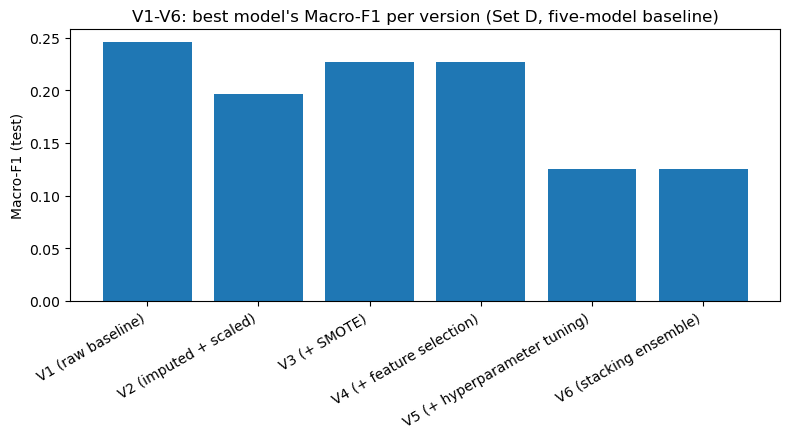

In [15]:
if "results" not in dir() or results is None:
    print("`results` is not available -- the run above did not complete "
          "(likely interrupted). Re-run the previous cell to completion first.")
else:
    summary_plot_df = results["summary"].dropna(subset=["F1 Test"])
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.bar(summary_plot_df["Version"], summary_plot_df["F1 Test"])
    ax.set_ylabel("Macro-F1 (test)")
    ax.set_title("V1-V6: best model's Macro-F1 per version (Set D, five-model baseline)")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig(out_path("fig_v1_v6_macro_f1.png"), dpi=200)
    plt.show()


## Final confusion matrix and classification report for the overall best configuration

Identifies the single best-performing (version, model) combination across every
version that actually completed in this run, and reports its confusion matrix and
per-class classification report -- using the exact fitted object and test data already
produced above, not a re-fit. If the run above was interrupted before returning
(`results` unavailable), this is skipped rather than fabricated.

**V1 is excluded from this selection.** V1's complete-case baseline evaluates on only
~662 records (a ~5% subsample after listwise deletion), so its test-set Macro-F1 is not
comparable to V2-V6, which evaluate on the full leakage-safe test split. Including V1
here would let its small, non-representative test set (and correspondingly noisier
F1) outrank the versions actually intended for comparison. This mirrors the same
V1-exclusion already applied when reporting the "best model" in the CatBoost
supplementary experiment.

Overall best configuration (V2-V6 only): V3 / SVM (Macro-F1 = 0.2271)
              precision    recall  f1-score   support

           0       0.10      0.04      0.06       139
           1       0.14      0.11      0.12        99
           2       0.34      0.39      0.36       233
           3       0.37      0.42      0.39       329
           4       0.00      0.00      0.00        54
           5       0.16      0.12      0.14       193
           6       0.25      0.23      0.24       150
           7       0.38      0.52      0.44       453
           8       0.30      0.28      0.29       346
           9       0.18      0.16      0.17       152
          10       0.29      0.29      0.29       418

    accuracy                           0.30      2566
   macro avg       0.23      0.23      0.23      2566
weighted avg       0.28      0.30      0.29      2566

Saved: /Users/narjishubail/Downloads/new/output/official_v1_v6_setD_final_model_classification_report.csv


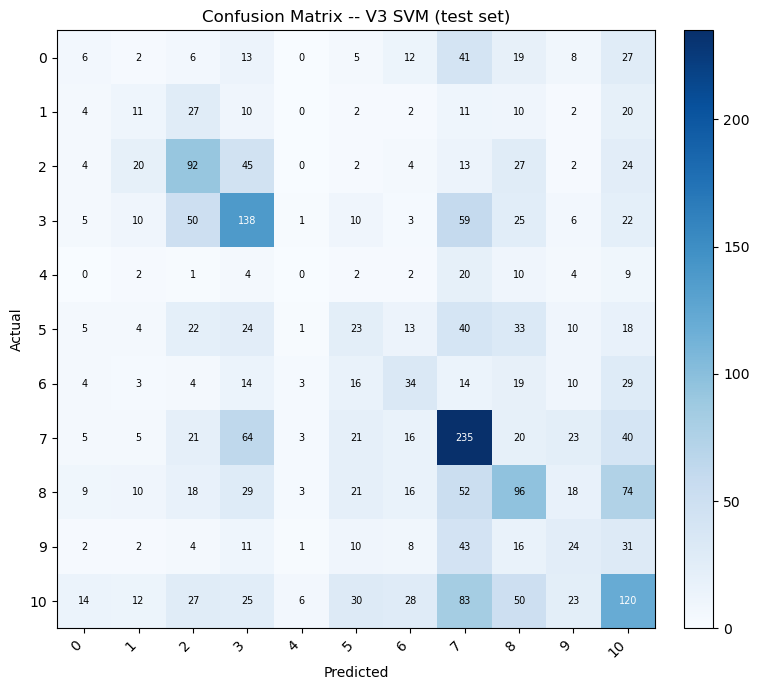

Exception ignored in: <function ResourceTracker.__del__ at 0x1028d5bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x10816dbc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1028e5bc0>
Traceback (most recent call last

In [16]:
if "results" not in dir() or results is None or not results.get("all_candidates"):
    print("Skipped: no completed run with tracked fitted candidates is available "
          "(the run above did not finish, or no version produced any result). "
          "Re-run to completion, then re-run this cell.")
else:
    # Exclude V1 -- see markdown above: its complete-case test set (~662 records) is
    # not comparable to V2-V6's full leakage-safe test split.
    eligible_candidates = [c for c in results["all_candidates"] if c["Version"] != "V1"]
    if not eligible_candidates:
        print("Skipped: no V2-V6 candidates available (only V1 completed, or all "
              "later versions failed). V1 is excluded from final-model selection "
              "because its complete-case test set is not comparable to V2-V6.")
    else:
        best_candidate = max(eligible_candidates, key=lambda c: c["row"]["F1 Test"])
        version = best_candidate["Version"]
        model_name = best_candidate["row"]["Model"]
        f1_test = best_candidate["row"]["F1 Test"]
        fitted_model = best_candidate["model"]
        X_test_best = best_candidate["X_test"]
        y_test_best = best_candidate["y_test"]

        print(f"Overall best configuration (V2-V6 only): {version} / {model_name} (Macro-F1 = {f1_test})")

        y_pred_best = fitted_model.predict(X_test_best)
        labels_sorted = sorted(pd.unique(np.concatenate([y_test_best, y_pred_best])).tolist())

        cm = confusion_matrix(y_test_best, y_pred_best, labels=labels_sorted)
        report_dict = classification_report(y_test_best, y_pred_best, labels=labels_sorted,
                                             output_dict=True, zero_division=0)
        report_df = pd.DataFrame(report_dict).transpose()
        report_path = out_path(f"{EXPERIMENT_TAG}_final_model_classification_report.csv")
        report_df.to_csv(report_path)
        print(classification_report(y_test_best, y_pred_best, labels=labels_sorted, zero_division=0))
        print(f"Saved: {report_path}")

        fig, ax = plt.subplots(figsize=(8, 7))
        im = ax.imshow(cm, cmap="Blues")
        ax.set_xticks(range(len(labels_sorted))); ax.set_xticklabels(labels_sorted, rotation=45, ha="right")
        ax.set_yticks(range(len(labels_sorted))); ax.set_yticklabels(labels_sorted)
        ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
        ax.set_title(f"Confusion Matrix -- {version} {model_name} (test set)")
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                ax.text(j, i, cm[i, j], ha="center", va="center",
                        color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=7)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        plt.tight_layout()
        plt.savefig(out_path("fig_confusion_matrix_final.png"), dpi=200)
        plt.show()


## Results Summary / Key Finding

*(Fill in from the printed output above once run to completion -- the notebook is
designed so V1-V3 results are saved even if V4-V6 are interrupted.)*

- This is the **official, primary** V1-V6 benchmark for the thesis (five originally
  approved classifiers: Decision Tree, Random Forest, SVM, KNN, Naive Bayes). It is
  distinct from, and takes precedence over, the CatBoost supplementary experiment for
  reporting which algorithm the approved methodology found best.
- The best model per version is reported neutrally in `results["summary"]` -- no
  algorithm is asserted in advance to outperform the others.
- V4's feature-selection sweep should be read against the V3 (all-features) baseline:
  state plainly whether any reduced feature configuration beat it, without pre-judging
  the outcome.
- V5 and V6's results (tuning and stacking) should be reported once available; if this
  run was interrupted before reaching them, that should be stated explicitly rather
  than left ambiguous, consistent with how the CatBoost supplementary experiment
  documents its own V5/V6 provenance.